# Cube-tower phase recovery with a NeuralMag BB phase field

This notebook keeps dataset selection, plotting, and saving local. The phase target preparation, NeuralMag state construction, scheduled minimization, support projection, and phase metrics live in `libertem_holo.base.mbir.neuralmag_phase_recovery`.


In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

import jax

jax.config.update("jax_enable_x64", True)

cwd = Path.cwd().resolve()
repo_root = next((path for path in (cwd, *cwd.parents) if (path / "pyproject.toml").exists()), cwd)
vendor_neuralmag = repo_root / "vendor/neuralmag"
if vendor_neuralmag.exists() and str(vendor_neuralmag) not in sys.path:
    sys.path.insert(0, str(vendor_neuralmag))

try:
    import neuralmag as nm
except ImportError as exc:
    raise ImportError(
        "This notebook requires NeuralMag in the active kernel. "
        "Use the same environment as neuralmag_cube_tower_from_mumax.ipynb."
    ) from exc

from libertem_holo.base.mbir import (
    NeuralMagPhaseRecoveryConfig,
    make_initial_m_cell,
    normalize_on_support,
    predict_neuralmag_phase,
    prepare_neuralmag_phase_target,
    run_neuralmag_phase_recovery,
    xyz_to_zyx,
)

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["image.origin"] = "lower"
np.set_printoptions(precision=4, suppress=True)



2026-04-24 15:29:03 NeuralMag:INFO [NeuralMag] Version 0.9.4


In [3]:
# Experiment configuration
fit_preset = "full"  # "debug", "medium", or "full"

output_dir = repo_root / "notebooks/MBIR/neuralmag_cube_tower_outputs"
output_npz = output_dir / "cube_tower_relaxed_comparison.npz"
target_orientation_name = "MuMax axes"
target_orientation_default = "0, 0, 1 Axis"

base_phase_weight_schedule = {
    "debug": (1e-3, 3e-3),
    "medium": (1e-4, 3e-4, 1e-3),
    "full": (1e-4, 3e-4, 1e-3, 3e-3, 1e-2),
}[fit_preset]

# "ramp" uses every weight in the schedule as a separate stage.
# "single" skips the ramp and runs only the strongest phase weight.
phase_schedule_mode = "single"

# Speed preset: "fast" (~3-4x faster), "normal" (full quality).
# fast: cheaper demag + coarse-grained volume; with a single stage we keep more BB iterations.
speed_preset = "fast"

stage_iterations = {
    "single": {
        "fast": {"debug": 24, "medium": 80, "full": 200},
        "normal": {"debug": 24, "medium": 80, "full": 200},
    },
    "ramp": {
        "fast": {"debug": 8, "medium": 25, "full": 120},
        "normal": {"debug": 12, "medium": 40, "full": 75},
    },
}[phase_schedule_mode][speed_preset][fit_preset]

demag_p = {"fast": 2, "normal": 3}[speed_preset]
phase_pad = {"fast": 64, "normal": 64}[speed_preset]
coarse_grain_factor = {"fast": 2, "normal": 1}[speed_preset]  # integer spatial downsampling

# Phase coupling knobs
phase_fit_scale = 0.35  # multiplied onto all weights; < 1.0 reduces phase pressure
phase_field_fraction = 0.05  # fraction of voxels used for phase calibration
if phase_schedule_mode == "single":
    phase_weight_schedule = (base_phase_weight_schedule[-1] * phase_fit_scale,)
else:
    phase_weight_schedule = tuple(v * phase_fit_scale for v in base_phase_weight_schedule)
crop_configs = {
    "debug": (64, 64, 64),
    "medium": (64, 64, 64),
    "full": None,
}
crop_shape = crop_configs[fit_preset]

anisotropy_configs = {
    "MuMax axes": (np.array([0.0, 0.0, 1.0], dtype=np.float32), np.array([0.0, 1.0, 0.0], dtype=np.float32)),
    "0, 0, 1 Axis": (np.array([0.0, 0.0, 1.0], dtype=np.float32), np.array([0.0, 1.0, 0.0], dtype=np.float32)),
    "1, 1, 1 Axis": (np.array([1.0, 1.0, 1.0], dtype=np.float32), np.array([1.0, -1.0, 0.0], dtype=np.float32)),
}

init_mode = "random"
rng_seed = 8

print(f"Fit preset: {fit_preset}  |  Speed preset: {speed_preset}  |  schedule: {phase_schedule_mode}")
print(f"Crop shape (XYZ): {crop_shape if crop_shape else 'full'}")
print(f"Phase-weight schedule (x{phase_fit_scale}): {phase_weight_schedule}")
print(
    f"Stages: {len(phase_weight_schedule)}  |  iterations/stage: {stage_iterations}  |  demag_p: {demag_p}  |  "
    f"phase pad: {phase_pad}  |  coarse_grain: {coarse_grain_factor}x"
 )


Fit preset: full  |  Speed preset: fast  |  schedule: single
Crop shape (XYZ): full
Phase-weight schedule (x0.35): (0.0034999999999999996,)
Stages: 1  |  iterations/stage: 200  |  demag_p: 2  |  phase pad: 64  |  coarse_grain: 2x


In [2]:
def load_saved_orientation(npz_path: Path):
    if not npz_path.exists():
        raise FileNotFoundError(f"Missing saved cube-tower output: {npz_path}")

    with np.load(npz_path, allow_pickle=True) as data:
        names = [str(name) for name in data["anisotropy_names"].tolist()]
        chosen = target_orientation_name if target_orientation_name in names else (
            target_orientation_default if target_orientation_default in names else names[0]
        )
        key = chosen.lower().replace(" ", "_")

        cellsize_nm = float(np.asarray(data["cellsize_nm"]))
        rho_xyz = np.asarray(data[f"rho_{key}"], dtype=np.float32)
        m_xyz = np.asarray(data[f"m_{key}"], dtype=np.float32)

    return chosen, cellsize_nm, rho_xyz, m_xyz

def coarse_grain_volume(
    rho_xyz: np.ndarray,
    m_xyz: np.ndarray,
    factor: int,
) -> tuple[np.ndarray, np.ndarray]:
    """Block-average rho and m by *factor* in each spatial dimension (XYZ).

    rho is averaged uniformly.  m is averaged with density weighting and
    renormalized to unit vectors on support (rho > 0.5).
    """
    if factor == 1:
        return rho_xyz, m_xyz
    nx, ny, nz = rho_xyz.shape[:3]
    # Trim to multiples of factor
    nx_t = (nx // factor) * factor
    ny_t = (ny // factor) * factor
    nz_t = (nz // factor) * factor
    rho_t = rho_xyz[:nx_t, :ny_t, :nz_t]
    m_t   = m_xyz  [:nx_t, :ny_t, :nz_t]
    s = (nx_t // factor, factor, ny_t // factor, factor, nz_t // factor, factor)
    # Block-average rho
    rho_cg = rho_t.reshape(s).mean(axis=(1, 3, 5))
    # Density-weighted block-sum of m, then divide by rho sum
    m_weighted = (m_t * rho_t[..., np.newaxis]).reshape(*s, 3).sum(axis=(1, 3, 5))
    rho_sum    = rho_t.reshape(s).sum(axis=(1, 3, 5))
    m_avg = m_weighted / np.maximum(rho_sum[..., np.newaxis], 1e-9)
    # Renormalize to unit vectors where rho > threshold
    nrm = np.linalg.norm(m_avg, axis=-1, keepdims=True)
    m_cg = np.where(rho_cg[..., np.newaxis] > 0.5, m_avg / np.where(nrm > 0, nrm, 1.0), 0.0)
    return rho_cg.astype(np.float32), m_cg.astype(np.float32)


In [4]:
chosen_name, cellsize_nm, rho_full_xyz, m_full_xyz = load_saved_orientation(output_npz)
axis1, axis2 = anisotropy_configs.get(chosen_name, anisotropy_configs[target_orientation_default])

# Coarse-grain the 3D volume for faster demag / forward-model computation
rho_cg_xyz, m_cg_xyz = coarse_grain_volume(rho_full_xyz, m_full_xyz, coarse_grain_factor)
cellsize_nm_cg = cellsize_nm * coarse_grain_factor
if coarse_grain_factor > 1:
    print(f"Coarse-grained {coarse_grain_factor}x: {rho_full_xyz.shape[:3]} -> {rho_cg_xyz.shape[:3]}, "
          f"cell {cellsize_nm:g} nm -> {cellsize_nm_cg:g} nm")

phase_image_shape_yx = (
    rho_cg_xyz.shape[1] + 2 * phase_pad,
    rho_cg_xyz.shape[0] + 2 * phase_pad,
)

recovery_config = NeuralMagPhaseRecoveryConfig(
    phase_weight_schedule=phase_weight_schedule,
    phase_pad=phase_pad,
    phase_field_fraction=phase_field_fraction,
    projection_axis="z",
    geometry="disc",
    init_mode=init_mode,
    rng_seed=rng_seed,
    Msat_A_per_m=480e3,
    Aex_J_per_m=1e-11,
    Kc1_J_per_m3=-1.35e4,
    demag_p=demag_p,
    anisotropy_axis1=axis1,
    anisotropy_axis2=axis2,
    minimizer_method="alternating",
    minimizer_update="cayley",
    minimizer_tol=1e-3,
    minimizer_max_iter=stage_iterations,
    minimizer_tau_min=1e-18,
    minimizer_tau_max=1e-4,
)

target = prepare_neuralmag_phase_target(
    rho_cg_xyz,
    m_cg_xyz,
    cellsize_nm=cellsize_nm_cg,
    config=recovery_config,
    crop_shape=crop_shape,
)

rho_xyz = target.rho_xyz
m_target_xyz = target.m_target_xyz
rho_zyx = target.rho_zyx
m_target_zyx = target.m_target_zyx
phase_target = target.phase_target
phase_mask = target.phase_mask
phase_mask_core = target.phase_mask_core

phase_mask_np = np.asarray(phase_mask) > 0.5
phase_mask_core_np = np.asarray(phase_mask_core) > 0.5
support_rows = np.flatnonzero(np.any(phase_mask_core_np, axis=1))
support_cols = np.flatnonzero(np.any(phase_mask_core_np, axis=0))
support_height = int(support_rows[-1] - support_rows[0] + 1) if support_rows.size else 0
support_width = int(support_cols[-1] - support_cols[0] + 1) if support_cols.size else 0

print(f"Saved orientation used as target: {chosen_name}")
print(f"Cell size: {cellsize_nm:g} nm")
print(f"rho_xyz shape: {rho_xyz.shape}; m_xyz shape: {m_target_xyz.shape}")
print(f"Computed phase image shape (Y, X): {phase_image_shape_yx}")
print(f"Target phase shape: {phase_target.shape}")
print(f"Projected support size (Y, X): ({support_height}, {support_width}) px")
print(f"Phase image padding: {phase_pad} px on every side")
print(f"Target phase range: [{float(phase_target.min()):.4g}, {float(phase_target.max()):.4g}] rad")
print(f"Fit region coverage: {float(phase_mask_np.mean()):.1%} of the computed phase image")
print(f"Support pixels: {int(phase_mask_core_np.sum())}")
print(f"Fit pixels: {int(phase_mask_np.sum())}")


Coarse-grained 2x: (112, 342, 56) -> (56, 171, 28), cell 3 nm -> 6 nm
Saved orientation used as target: 0, 0, 1 Axis
Cell size: 3 nm
rho_xyz shape: (56, 171, 28); m_xyz shape: (56, 171, 28, 3)
Computed phase image shape (Y, X): (299, 184)
Target phase shape: (299, 184)
Projected support size (Y, X): (170, 28) px
Phase image padding: 64 px on every side
Target phase range: [-18.46, 18.46] rad
Fit region coverage: 100.0% of the computed phase image
Support pixels: 4704
Fit pixels: 55016


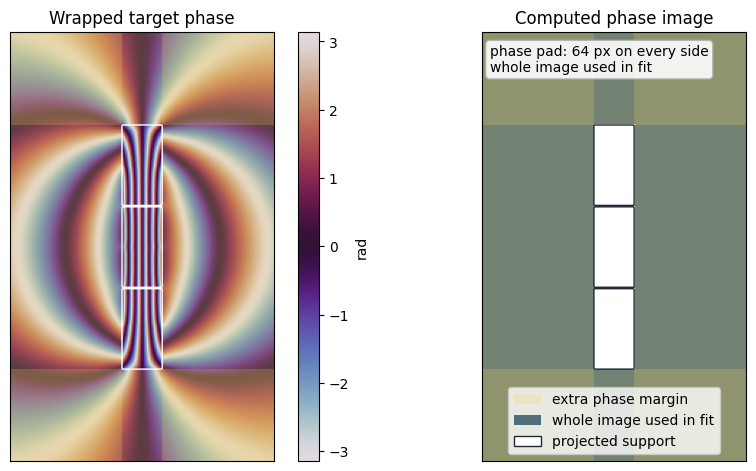

In [5]:
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.patches import Patch

wrapped_phase = np.angle(np.exp(1j * np.asarray(phase_target)))
phase_mask_np = np.asarray(phase_mask) > 0.5
phase_mask_core_np = np.asarray(phase_mask_core) > 0.5
support_rows = np.flatnonzero(np.any(phase_mask_core_np, axis=1))
support_cols = np.flatnonzero(np.any(phase_mask_core_np, axis=0))
if support_rows.size:
    y0 = int(support_rows[0])
    y1 = int(support_rows[-1])
else:
    y0 = 0
    y1 = wrapped_phase.shape[0] - 1
if support_cols.size:
    x0 = int(support_cols[0])
    x1 = int(support_cols[-1])
else:
    x0 = 0
    x1 = wrapped_phase.shape[1] - 1

extent_map = np.ones_like(wrapped_phase, dtype=np.int8)
extent_map[phase_mask_core_np] = 2

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.6), constrained_layout=True)

im = axes[0].imshow(wrapped_phase, cmap="twilight", vmin=-np.pi, vmax=np.pi)
axes[0].axhspan(-0.5, y0 - 0.5, color="#f4d35e", alpha=0.22, lw=0)
axes[0].axhspan(y1 + 0.5, wrapped_phase.shape[0] - 0.5, color="#f4d35e", alpha=0.22, lw=0)
axes[0].axvspan(-0.5, x0 - 0.5, color="#f4d35e", alpha=0.22, lw=0)
axes[0].axvspan(x1 + 0.5, wrapped_phase.shape[1] - 0.5, color="#f4d35e", alpha=0.22, lw=0)
axes[0].contour(phase_mask_core_np, levels=[0.5], colors="w", linewidths=1.0)
axes[0].set_title("Wrapped target phase")
plt.colorbar(im, ax=axes[0], fraction=0.046, label="rad")

extent_cmap = ListedColormap(["#4f6d7a", "#ffffff"])
extent_norm = BoundaryNorm([0.5, 1.5, 2.5], extent_cmap.N)
axes[1].imshow(extent_map, cmap=extent_cmap, norm=extent_norm, interpolation="nearest")
axes[1].axhspan(-0.5, y0 - 0.5, color="#f4d35e", alpha=0.22, lw=0)
axes[1].axhspan(y1 + 0.5, wrapped_phase.shape[0] - 0.5, color="#f4d35e", alpha=0.22, lw=0)
axes[1].axvspan(-0.5, x0 - 0.5, color="#f4d35e", alpha=0.22, lw=0)
axes[1].axvspan(x1 + 0.5, wrapped_phase.shape[1] - 0.5, color="#f4d35e", alpha=0.22, lw=0)
axes[1].contour(phase_mask_core_np, levels=[0.5], colors="#1f2933", linewidths=1.0)
axes[1].set_title("Computed phase image")
axes[1].text(
    0.03,
    0.97,
    f"phase pad: {phase_pad} px on every side\nwhole image used in fit",
    transform=axes[1].transAxes,
    va="top",
    ha="left",
    bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.9, "edgecolor": "0.7"},
)

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

axes[1].legend(
    handles=[
        Patch(facecolor="#f4d35e", alpha=0.22, label="extra phase margin"),
        Patch(facecolor="#4f6d7a", label="whole image used in fit"),
        Patch(facecolor="#ffffff", edgecolor="#1f2933", label="projected support"),
    ],
    loc="lower center",
    frameon=True,
)
plt.show()


In [6]:
result = run_neuralmag_phase_recovery(
    target,
    config=recovery_config,
)

first = result.history[0]
last = result.history[-1]

print(f"COMPLETE: {result.n_iter} compiled BB iterations")
print(f"Phase RMS: {first['phase_rms']:.6g} -> {last['phase_rms']:.6g}")
print(f"Projected error: {first['projected_error']:.6g} -> {last['projected_error']:.6g}")
print(f"Final max_g: {result.max_g:.6g}")
print(f"Phase energy scale: {result.phase_energy_scale:.6g}")


2026-04-24 15:29:46 NeuralMag:INFO [NeuralMag] Backend set to 'jax'.
2026-04-24 15:29:46 NeuralMag:INFO [Mesh] 3D, 56 x 171 x 28 (size = 6e-09 x 6e-09 x 6e-09)
2026-04-24 15:29:46 NeuralMag:INFO [NeuralMag] Set default device to 'cuda:0'.
2026-04-24 15:29:46 NeuralMag:INFO [NeuralMag] Set default dtype to 'float32'.
2026-04-24 15:29:46 NeuralMag:INFO [State] Running on device: cuda:0 (dtype = float32, backend = jax)
2026-04-24 15:29:46 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange', energy density: 'e_exchange')
2026-04-24 15:29:46 NeuralMag:INFO [DemagField] Register state methods (field: 'h_demag', energy: 'E_demag', energy density: 'e_demag')
2026-04-24 15:29:46 NeuralMag:INFO [DemagField]: Set up demag tensor
2026-04-24 15:29:50 NeuralMag:INFO [CubicAnisotropyField] Register state methods (field: 'h_cubic', energy: 'E_cubic', energy density: 'e_cubic')
2026-04-24 15:29:50 NeuralMag:INFO [TotalField] Register state methods (field: 'h

COMPLETE: 200 compiled BB iterations
Phase RMS: 8.81569 -> 2.62357
Projected error: 1.01389 -> 0.312705
Final max_g: 27404.5
Phase energy scale: 1.25333e+10


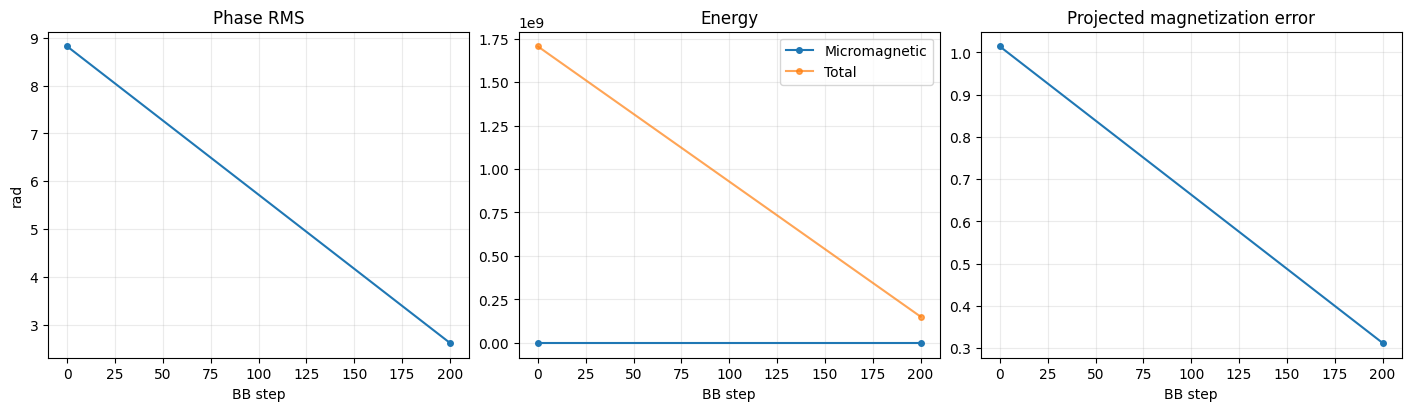

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
history = result.history
steps = [row["global_step"] for row in history]

axes[0].plot(steps, [row["phase_rms"] for row in history], marker="o", ms=4)
axes[0].set_title("Phase RMS")
axes[0].set_ylabel("rad")

axes[1].plot(steps, [row["E_micromagnetic"] for row in history], marker="o", ms=4, label="Micromagnetic")
axes[1].plot(steps, [row["E_total"] for row in history], marker="o", ms=4, label="Total", alpha=0.7)
axes[1].set_title("Energy")
axes[1].legend()

axes[2].plot(steps, [row["projected_error"] for row in history], marker="o", ms=4)
axes[2].set_title("Projected magnetization error")

for boundary in sorted({row["global_step"] for row in history if row.get("event") == "start" and row.get("stage", 0) > 0}):
    for ax in axes:
        ax.axvline(boundary, color="0.5", lw=0.8, ls="--", alpha=0.5)

for ax in axes:
    ax.set_xlabel("BB step")
    ax.grid(True, alpha=0.25)
plt.show()


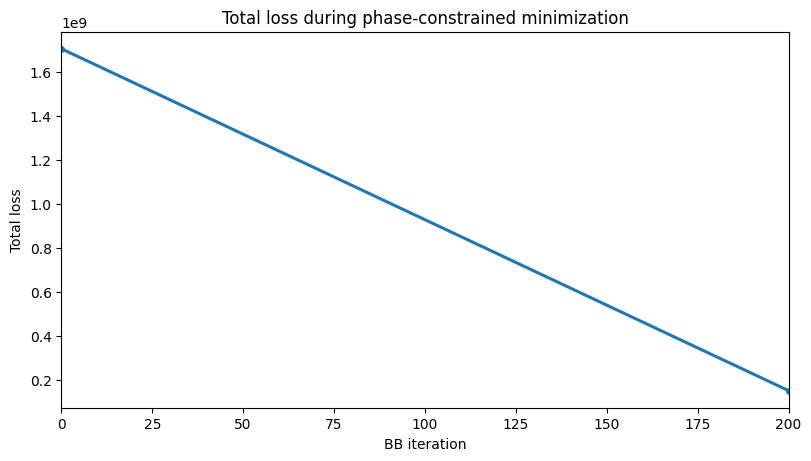

Loss summary:
  Initial total loss: 1.704580e+09
  Final total loss:   1.509695e+08
  Reduction:          91.14%


In [8]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4.5), constrained_layout=True)

history = result.history
steps = np.array([row["global_step"] for row in history], dtype=float)
total_loss = np.array([row["E_total"] for row in history], dtype=float)

ax.plot(steps, total_loss, linewidth=2.2, marker="o", ms=4)
ax.set_xlabel("BB iteration")
ax.set_ylabel("Total loss")
ax.set_title("Total loss during phase-constrained minimization")
ax.set_xlim(steps[0], steps[-1])
plt.show()

loss_change_pct = (total_loss[0] - total_loss[-1]) / total_loss[0] * 100 if total_loss[0] != 0 else np.nan
print("Loss summary:")
print(f"  Initial total loss: {total_loss[0]:.6e}")
print(f"  Final total loss:   {total_loss[-1]:.6e}")
print(f"  Reduction:          {loss_change_pct:.2f}%")


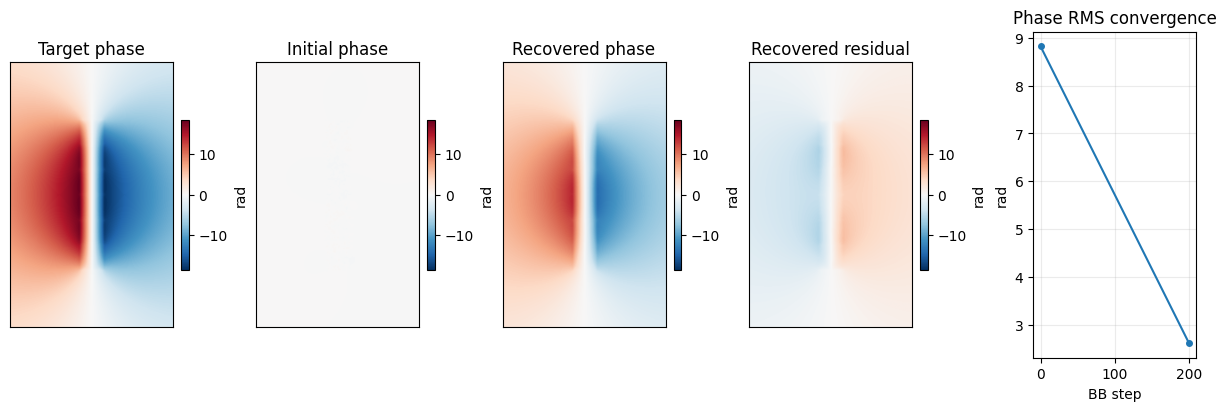

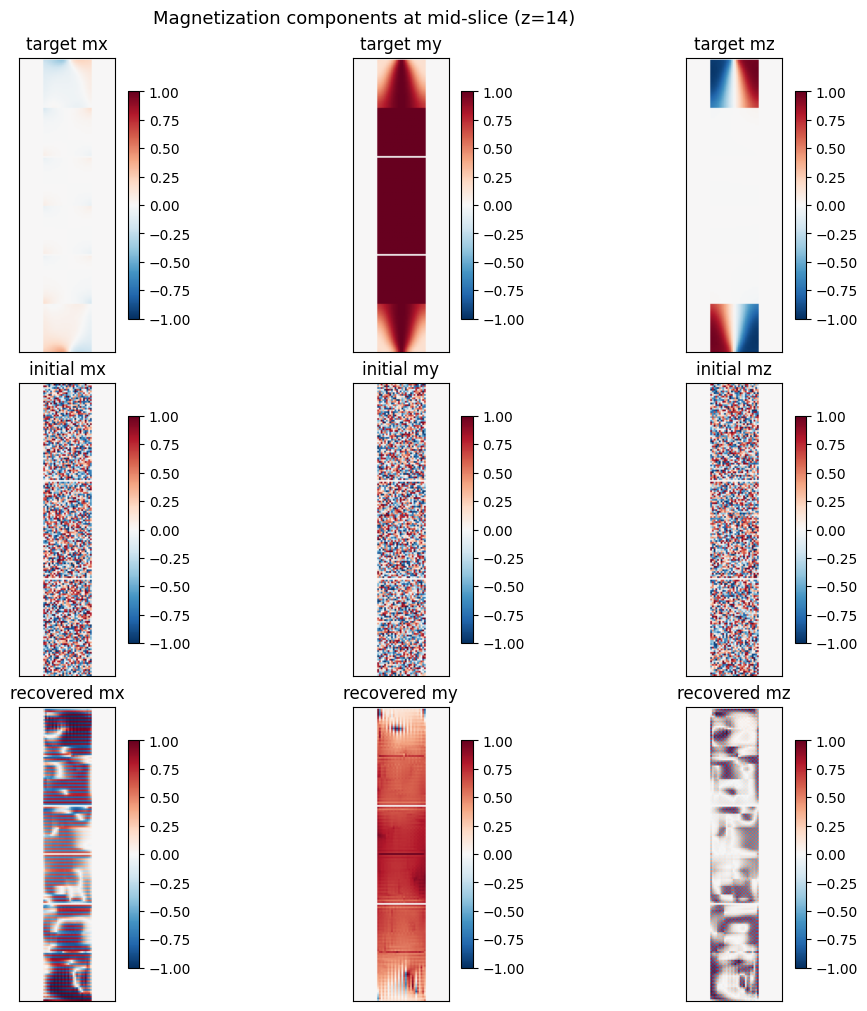

Initial vs final metrics:
  Initial phase RMS: 8.81569 rad
  Final phase RMS:   2.62357 rad
  3D RMSE:           0.53297
  Projected error:   0.312705
  Off-support leak:  0


In [9]:
best_m_cell_xyz = result.m_recovered_xyz
best_m_zyx = xyz_to_zyx(best_m_cell_xyz)

initial_m_cell_xyz = make_initial_m_cell(
    rho_xyz,
    m_target_xyz,
    mode=init_mode,
    rng_seed=rng_seed,
)
initial_m_zyx = xyz_to_zyx(initial_m_cell_xyz)
initial_phase = np.asarray(predict_neuralmag_phase(initial_m_cell_xyz, target, recovery_config), dtype=np.float32)
best_phase = result.phase_recovered
target_phase_np = np.asarray(phase_target, dtype=np.float32)
mask_np = np.asarray(phase_mask, dtype=np.float32)

residual = (best_phase - target_phase_np) * mask_np
initial_residual = (initial_phase - target_phase_np) * mask_np

vmax_phase = max(
    abs(float(target_phase_np.min())), abs(float(target_phase_np.max())),
    abs(float(initial_phase.min())), abs(float(initial_phase.max())),
    abs(float(best_phase.min())), abs(float(best_phase.max())),
)

fig, axes = plt.subplots(1, 5, figsize=(12, 4), constrained_layout=True)

for ax, image, title in [
    (axes[0], target_phase_np, "Target phase"),
    (axes[1], initial_phase, "Initial phase"),
    (axes[2], best_phase, "Recovered phase"),
    (axes[3], residual, "Recovered residual"),
]:
    im = ax.imshow(image, cmap="RdBu_r", vmin=-vmax_phase, vmax=vmax_phase)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046, label="rad")

axes[4].plot([row["global_step"] for row in result.history], [row["phase_rms"] for row in result.history], marker="o", ms=4)
axes[4].set_title("Phase RMS convergence")
axes[4].set_xlabel("BB step")
axes[4].set_ylabel("rad")
axes[4].grid(True, alpha=0.25)
plt.show()

mid = best_m_zyx.shape[0] // 2
component_labels = ["mx", "my", "mz"]
fig, axes = plt.subplots(3, 3, figsize=(10, 10), constrained_layout=True, sharex=True, sharey=True)

for col, label in enumerate(component_labels):
    for row, (name, volume) in enumerate([
        ("target", m_target_zyx),
        ("initial", initial_m_zyx),
        ("recovered", best_m_zyx),
    ]):
        im = axes[row, col].imshow(np.asarray(volume[mid, ..., col]), cmap="RdBu_r", vmin=-1, vmax=1)
        axes[row, col].set_title(f"{name} {label}")
        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])
        plt.colorbar(im, ax=axes[row, col], fraction=0.046)

plt.suptitle(f"Magnetization components at mid-slice (z={mid})", fontsize=13)
plt.show()

denom = max(float(mask_np.sum()), 1.0)
initial_phase_rms = float(np.sqrt(np.sum(initial_residual * initial_residual) / denom))
final = result.history[-1]
print("Initial vs final metrics:")
print(f"  Initial phase RMS: {initial_phase_rms:.6g} rad")
print(f"  Final phase RMS:   {final['phase_rms']:.6g} rad")
print(f"  3D RMSE:           {final['rmse_3d']:.6g}")
print(f"  Projected error:   {final['projected_error']:.6g}")
print(f"  Off-support leak:  {final['off_support_leak']:.6g}")


In [10]:
save_result = True
if save_result:
    out_path = output_dir / f"phase_recovery_{fit_preset}.npz"
    np.savez_compressed(
        out_path,
        cellsize_nm=np.float32(cellsize_nm),
        fit_preset=np.array(fit_preset, dtype=object),
        target_orientation=np.array(chosen_name, dtype=object),
        phase_weight_schedule=np.asarray(phase_weight_schedule, dtype=np.float32),
        phase_energy_scale=np.asarray(result.phase_energy_scale, dtype=np.float32),
        rho_xyz=np.asarray(rho_xyz, dtype=np.float32),
        m_target_xyz=np.asarray(m_target_xyz, dtype=np.float32),
        m_recovered_xyz=np.asarray(best_m_cell_xyz, dtype=np.float32),
        phase_target=np.asarray(phase_target, dtype=np.float32),
        phase_recovered=np.asarray(best_phase, dtype=np.float32),
        phase_mask=np.asarray(phase_mask, dtype=np.float32),
        history=np.asarray(result.history, dtype=object),
    )
    print(f"Saved: {out_path}")


Saved: /Users/landers/LiberTEM-holo/notebooks/MBIR/neuralmag_cube_tower_outputs/phase_recovery_full.npz


## Notes

The notebook now delegates the phase field, support projection, calibration, metrics, and scheduled minimization to the MBIR NeuralMag phase-recovery API. The run uses NeuralMag's compiled minimizer once per phase-weight stage, with sparse start/end metrics for speed.


In [11]:
history = result.history
first = history[0]
last = history[-1]
phase_rms_values = np.array([row["phase_rms"] for row in history], dtype=float)
total_loss_values = np.array([row["E_total"] for row in history], dtype=float)
projected_error_values = np.array([row["projected_error"] for row in history], dtype=float)

print({
    "n_iter": int(result.n_iter),
    "phase_rms_start": float(first["phase_rms"]),
    "phase_rms_end": float(last["phase_rms"]),
    "phase_rms_drop_pct": float((phase_rms_values[0] - phase_rms_values[-1]) / phase_rms_values[0] * 100.0),
    "total_loss_start": float(total_loss_values[0]),
    "total_loss_end": float(total_loss_values[-1]),
    "total_loss_drop_pct": float((total_loss_values[0] - total_loss_values[-1]) / total_loss_values[0] * 100.0),
    "projected_error_start": float(projected_error_values[0]),
    "projected_error_end": float(projected_error_values[-1]),
    "projected_error_drop_pct": float((projected_error_values[0] - projected_error_values[-1]) / projected_error_values[0] * 100.0),
    "max_g": float(result.max_g),
})

{'n_iter': 200, 'phase_rms_start': 8.815690040588379, 'phase_rms_end': 2.623567581176758, 'phase_rms_drop_pct': 70.23979326521722, 'total_loss_start': 1704580132.609676, 'total_loss_end': 150969529.1450796, 'total_loss_drop_pct': 91.14330114161612, 'projected_error_start': 1.013890027999878, 'projected_error_end': 0.3127049505710602, 'projected_error_drop_pct': 69.15790254018577, 'max_g': 27404.51171875}


In [12]:
from dataclasses import replace
import importlib
import libertem_holo.base.mbir.neuralmag_phase_recovery as neuralmag_phase_recovery

neuralmag_phase_recovery = importlib.reload(neuralmag_phase_recovery)
run_neuralmag_phase_recovery = neuralmag_phase_recovery.run_neuralmag_phase_recovery
recovery_cellsize_nm = float(target.cellsize_nm)

warmup_steps = min(50, max(stage_iterations // 4, 1))
phase_steps_after_warmup = max(stage_iterations - warmup_steps, 1)

baseline_config = replace(
    recovery_config,
    phase_weight_schedule=(0.0,),
    phase_energy_scale=1.0,
)
baseline_result = run_neuralmag_phase_recovery(
    rho_xyz,
    m_target_xyz,
    cellsize_nm=recovery_cellsize_nm,
    config=baseline_config,
)

warmup_config = replace(
    recovery_config,
    phase_weight_schedule=(0.0,),
    phase_energy_scale=1.0,
    minimizer_max_iter=warmup_steps,
)
warmup_result = run_neuralmag_phase_recovery(
    rho_xyz,
    m_target_xyz,
    cellsize_nm=recovery_cellsize_nm,
    config=warmup_config,
)
phase_after_warmup_config = replace(
    recovery_config,
    minimizer_max_iter=phase_steps_after_warmup,
)
warm_start_result = run_neuralmag_phase_recovery(
    rho_xyz,
    m_target_xyz,
    cellsize_nm=recovery_cellsize_nm,
    config=phase_after_warmup_config,
    m0_cell_xyz=warmup_result.m_recovered_xyz,
)

phase_last = result.history[-1]
baseline_last = baseline_result.history[-1]
warm_start_last = warm_start_result.history[-1]

print({
    "phase_on_direct": {
        "n_iter": int(result.n_iter),
        "phase_rms": float(phase_last["phase_rms"]),
        "projected_error": float(phase_last["projected_error"]),
        "rmse_3d": float(phase_last["rmse_3d"]),
        "max_g": float(result.max_g),
    },
    "phase_off_only": {
        "n_iter": int(baseline_result.n_iter),
        "phase_rms": float(baseline_last["phase_rms"]),
        "projected_error": float(baseline_last["projected_error"]),
        "rmse_3d": float(baseline_last["rmse_3d"]),
        "max_g": float(baseline_result.max_g),
    },
    "physics_then_phase": {
        "warmup_steps": int(warmup_result.n_iter),
        "phase_steps": int(warm_start_result.n_iter),
        "n_iter": int(warmup_result.n_iter + warm_start_result.n_iter),
        "phase_rms": float(warm_start_last["phase_rms"]),
        "projected_error": float(warm_start_last["projected_error"]),
        "rmse_3d": float(warm_start_last["rmse_3d"]),
        "max_g": float(warm_start_result.max_g),
    },
})

2026-04-24 15:32:18 NeuralMag:INFO [Mesh] 3D, 56 x 171 x 28 (size = 6e-09 x 6e-09 x 6e-09)
2026-04-24 15:32:18 NeuralMag:INFO [NeuralMag] Set default device to 'cuda:0'.
2026-04-24 15:32:18 NeuralMag:INFO [State] Running on device: cuda:0 (dtype = float32, backend = jax)
2026-04-24 15:32:18 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange', energy density: 'e_exchange')
2026-04-24 15:32:18 NeuralMag:INFO [DemagField] Register state methods (field: 'h_demag', energy: 'E_demag', energy density: 'e_demag')
2026-04-24 15:32:18 NeuralMag:INFO [DemagField]: Set up demag tensor


2026-04-24 15:32:20 NeuralMag:INFO [CubicAnisotropyField] Register state methods (field: 'h_cubic', energy: 'E_cubic', energy density: 'e_cubic')
2026-04-24 15:32:20 NeuralMag:INFO [TotalField] Register state methods (field: 'h_micromagnetic', energy: 'E_micromagnetic', energy density: 'e_micromagnetic')
2026-04-24 15:32:20 NeuralMag:INFO [TotalField] Register state methods (field: 'h', energy: 'E', energy density: 'e')
2026-04-24 15:32:45 NeuralMag:INFO [EnergyMinimizerJAX] Minimization started, initial energy E = 2.3555e-15 J
2026-04-24 15:33:00 NeuralMag:INFO [EnergyMinimizerJAX] Initial state 0/200: max_g = 914350 (tol = 0.001, converged = False)
2026-04-24 15:33:20 NeuralMag:INFO [EnergyMinimizerJAX] Final state 200/200: max_g = 168289 (tol = 0.001, converged = False)
2026-04-24 15:33:20 NeuralMag:INFO [EnergyMinimizerJAX] Minimization finished after 200 steps, final energy E = 1.52184e-17 J, converged = False
2026-04-24 15:33:20 NeuralMag:INFO [Mesh] 3D, 56 x 171 x 28 (size = 6e-

{'phase_on_direct': {'n_iter': 200, 'phase_rms': 2.623567581176758, 'projected_error': 0.3127049505710602, 'rmse_3d': 0.5329703092575073, 'max_g': 27404.51171875}, 'phase_off_only': {'n_iter': 200, 'phase_rms': 8.821154594421387, 'projected_error': 1.0006746053695679, 'rmse_3d': 0.8165051937103271, 'max_g': 168289.34375}, 'physics_then_phase': {'warmup_steps': 50, 'phase_steps': 150, 'n_iter': 200, 'phase_rms': 2.5830516815185547, 'projected_error': 0.30696991086006165, 'rmse_3d': 0.5311471819877625, 'max_g': 360494.03125}}


In [ ]:
from dataclasses import replace

import importlib

import libertem_holo.base.mbir.neuralmag_phase_recovery as neuralmag_phase_recovery



neuralmag_phase_recovery = importlib.reload(neuralmag_phase_recovery)

prepare_neuralmag_phase_target = neuralmag_phase_recovery.prepare_neuralmag_phase_target

select_anisotropy_orientation_from_phase = neuralmag_phase_recovery.select_anisotropy_orientation_from_phase



candidate_names = [name for name in ("0, 0, 1 Axis", "1, 1, 1 Axis") if name in anisotropy_configs]

if len(candidate_names) != 2:

    raise ValueError(f"Expected exactly two physical anisotropy candidates, got {candidate_names!r}.")



orientation_candidates = {name: anisotropy_configs[name] for name in candidate_names}

selection_stage_iterations = 40

selection_warmup_steps = 0

selection_error_threshold = 0.60

random_start_seed = rng_seed



selection_config = replace(

    recovery_config,

    phase_weight_schedule=(phase_weight_schedule[-1],),

    minimizer_max_iter=selection_stage_iterations,

    init_mode="random",

)



experiment_modes = {

    "candidate_warm_start": {

        "label": "Candidate-specific relaxed starts",

        "selection_metric": "initial_phase_rms",

        "use_candidate_initial_m0": True,

        "rng_seed": random_start_seed,

    },

    "shared_random_start": {

        "label": f"Shared random start (seed={random_start_seed})",

        "selection_metric": "final_phase_rms",

        "use_candidate_initial_m0": False,

        "rng_seed": random_start_seed,

    },

}





def build_candidate_initial_states(data, target_case):

    candidate_initial_states = {}

    for candidate_name in candidate_names:

        candidate_key = candidate_name.lower().replace(" ", "_")

        rho_full_guess_xyz = np.asarray(data[f"rho_{candidate_key}"], dtype=np.float32)

        m_full_guess_xyz = np.asarray(data[f"m_{candidate_key}"], dtype=np.float32)

        _, m_guess_xyz = coarse_grain_volume(

            rho_full_guess_xyz,

            m_full_guess_xyz,

            coarse_grain_factor,

        )

        m_guess_xyz = np.asarray(

            neuralmag_phase_recovery.center_crop(m_guess_xyz, crop_shape),

            dtype=np.float32,

        )

        candidate_initial_states[candidate_name] = normalize_on_support(

            m_guess_xyz,

            target_case.rho_xyz,

            threshold=selection_config.support_threshold,

        )

    return candidate_initial_states





def project_components_xy(m_xyz, rho_xyz):

    rho_xyz = np.asarray(rho_xyz, dtype=np.float32)

    m_xyz = np.asarray(m_xyz, dtype=np.float32)

    projected = np.sum(m_xyz * rho_xyz[..., np.newaxis], axis=2)

    thickness_xy = np.sum(rho_xyz, axis=2)

    return projected / np.maximum(thickness_xy[..., np.newaxis], 1e-6)





orientation_experiments = {}

summary_rows = []



with np.load(output_npz, allow_pickle=True) as data:

    saved_names = [str(name) for name in data["anisotropy_names"].tolist()]



    for target_name in candidate_names:

        if target_name not in saved_names:

            raise ValueError(f"Target orientation {target_name!r} is not present in {output_npz}.")



        key = target_name.lower().replace(" ", "_")

        rho_full_case_xyz = np.asarray(data[f"rho_{key}"], dtype=np.float32)

        m_full_case_xyz = np.asarray(data[f"m_{key}"], dtype=np.float32)

        rho_case_xyz, m_case_xyz = coarse_grain_volume(

            rho_full_case_xyz,

            m_full_case_xyz,

            coarse_grain_factor,

        )



        target_case = prepare_neuralmag_phase_target(

            rho_case_xyz,

            m_case_xyz,

            cellsize_nm=cellsize_nm_cg,

            config=selection_config,

            crop_shape=crop_shape,

        )

        target_projection_xyz = project_components_xy(target_case.m_target_xyz, target_case.rho_xyz)

        candidate_initial_m0 = build_candidate_initial_states(data, target_case)



        mode_runs = {}

        for mode_name, mode in experiment_modes.items():

            mode_config = replace(

                selection_config,

                rng_seed=mode["rng_seed"],

            )

            selection = select_anisotropy_orientation_from_phase(

                target_case,

                candidates=orientation_candidates,

                config=mode_config,

                candidate_m0_cell_xyz=candidate_initial_m0 if mode["use_candidate_initial_m0"] else None,

                warmup_steps=selection_warmup_steps,

                selection_metric=mode["selection_metric"],

            )



            best_fit = selection.best_fit

            initial_phase_scores = np.asarray([fit.initial_phase_rms for fit in selection.fits], dtype=float)

            final_phase_scores = np.asarray([fit.final_phase_rms for fit in selection.fits], dtype=float)

            final_component_rmse_xyz = np.asarray(best_fit.component_rmse_xyz, dtype=float)

            mode_runs[mode_name] = {

                "mode_label": mode["label"],

                "selection_metric": mode["selection_metric"],

                "selection": selection,

                "best_fit": best_fit,

                "best_name": selection.best_name,

                "fit_projection_xyz": project_components_xy(best_fit.result.m_recovered_xyz, target_case.rho_xyz),

                "initial_phase_rms": float(best_fit.initial_phase_rms),

                "final_phase_rms": float(best_fit.final_phase_rms),

                "initial_phase_score_spread": float(np.ptp(initial_phase_scores)),

                "final_phase_score_spread": float(np.ptp(final_phase_scores)),

                "initial_component_rmse_xyz": np.asarray(best_fit.initial_component_rmse_xyz, dtype=float),

                "initial_component_rmse_mean": float(np.nanmean(best_fit.initial_component_rmse_xyz)),

                "final_component_rmse_xyz": final_component_rmse_xyz,

                "final_component_rmse_mean": float(np.nanmean(final_component_rmse_xyz)),

                "orientation_correct": selection.best_name == target_name,

                "below_threshold": bool(np.nanmean(final_component_rmse_xyz) < selection_error_threshold),

            }



            for fit in selection.fits:

                summary_rows.append({

                    "target_orientation": target_name,

                    "mode": mode_name,

                    "candidate_orientation": fit.name,

                    "is_best": fit.name == selection.best_name,

                    "initial_phase_rms": float(fit.initial_phase_rms),

                    "final_phase_rms": float(fit.final_phase_rms),

                    "initial_component_rmse_mean": float(np.nanmean(fit.initial_component_rmse_xyz)),

                    "final_component_rmse_mean": float(np.nanmean(fit.component_rmse_xyz)),

                })



        orientation_experiments[target_name] = {

            "target": target_case,

            "target_projection_xyz": target_projection_xyz,

            "runs": mode_runs,

        }



print(

    "Shared random start cannot use initial_phase_rms for ranking: before relaxation the predicted phase only depends on the starting magnetization, not on the anisotropy axes."

)



for target_name, experiment in orientation_experiments.items():

    for mode_name, run in experiment["runs"].items():

        print({

            "target_orientation": target_name,

            "mode": run["mode_label"],

            "selection_metric": run["selection_metric"],

            "best_orientation": run["best_name"],

            "initial_phase_rms": float(run["initial_phase_rms"]),

            "final_phase_rms": float(run["final_phase_rms"]),

            "initial_phase_score_spread": float(run["initial_phase_score_spread"]),

            "final_phase_score_spread": float(run["final_phase_score_spread"]),

            "initial_component_rmse_mean": float(run["initial_component_rmse_mean"]),

            "final_component_rmse_xyz": np.asarray(run["final_component_rmse_xyz"]).round(4).tolist(),

            "final_component_rmse_mean": float(run["final_component_rmse_mean"]),

            "orientation_correct": bool(run["orientation_correct"]),

            "below_threshold": bool(run["below_threshold"]),

        })



mode_success = {}

for mode_name in experiment_modes:

    mode_success[mode_name] = all(

        orientation_experiments[target_name]["runs"][mode_name]["orientation_correct"]

        and orientation_experiments[target_name]["runs"][mode_name]["below_threshold"]

        for target_name in candidate_names

    )



print({

    "selection_stage_iterations": int(selection_stage_iterations),

    "selection_warmup_steps": int(selection_warmup_steps),

    "component_rmse_threshold": float(selection_error_threshold),

    "mode_success": mode_success,

})



fig, axes = plt.subplots(

    len(candidate_names),

    len(experiment_modes),

    figsize=(13, 4 * len(candidate_names)),

    constrained_layout=True,

    squeeze=False,

)



for row, target_name in enumerate(candidate_names):

    for col, (mode_name, mode) in enumerate(experiment_modes.items()):

        run = orientation_experiments[target_name]["runs"][mode_name]

        fits = run["selection"].fits

        score_values = [

            fit.initial_phase_rms if run["selection_metric"] == "initial_phase_rms" else fit.final_phase_rms

            for fit in fits

        ]

        axes[row, col].bar(

            [fit.name for fit in fits],

            score_values,

            color=["#1f77b4" if fit.name == run["best_name"] else "#c7c7c7" for fit in fits],

        )

        axes[row, col].set_title(f"{target_name}: {run['mode_label']}")

        axes[row, col].set_ylabel("phase RMS")

        axes[row, col].tick_params(axis="x", rotation=15)

        axes[row, col].text(

            0.03,

            0.97,

            f"metric: {run['selection_metric']}\nselected: {run['best_name']}\nfinal mean RMSE: {run['final_component_rmse_mean']:.3f}",

            transform=axes[row, col].transAxes,

            va="top",

            ha="left",

            bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.9, "edgecolor": "0.7"},

        )

        if mode_name == "shared_random_start":

            axes[row, col].text(

                0.03,

                0.05,

                f"initial score spread: {run['initial_phase_score_spread']:.2e}",

                transform=axes[row, col].transAxes,

                va="bottom",

                ha="left",

                bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.9, "edgecolor": "0.7"},

            )



plt.show()



fig, axes = plt.subplots(

    len(candidate_names),

    len(experiment_modes),

    figsize=(13, 4 * len(candidate_names)),

    constrained_layout=True,

    squeeze=False,

)

component_labels = ["mx", "my", "mz"]

component_x = np.arange(len(component_labels))



for row, target_name in enumerate(candidate_names):

    for col, (mode_name, mode) in enumerate(experiment_modes.items()):

        run = orientation_experiments[target_name]["runs"][mode_name]

        axes[row, col].bar(

            component_x,

            run["final_component_rmse_xyz"],

            width=0.62,

            color="#2ca02c",

        )

        axes[row, col].axhline(selection_error_threshold, color="#d62728", ls="--", lw=1.2)

        axes[row, col].set_xticks(component_x, component_labels)

        axes[row, col].set_ylim(

            0.0,

            max(

                selection_error_threshold * 1.35,

                float(np.nanmax(run["final_component_rmse_xyz"])) * 1.2,

            ),

        )

        axes[row, col].set_title(f"{target_name}: {run['mode_label']} -> {run['best_name']}")

        axes[row, col].set_ylabel("support RMSE")



plt.show()



projection_rows = [

    ("target", "Target"),

    ("candidate_warm_start", experiment_modes["candidate_warm_start"]["label"]),

    ("shared_random_start", experiment_modes["shared_random_start"]["label"]),

]

fig, axes = plt.subplots(

    len(candidate_names) * len(projection_rows),

    len(component_labels),

    figsize=(11, 3.2 * len(candidate_names) * len(projection_rows)),

    constrained_layout=True,

    squeeze=False,

)

last_im = None

row_index = 0



for target_name in candidate_names:

    experiment = orientation_experiments[target_name]

    for projection_key, row_label in projection_rows:

        if projection_key == "target":

            projection_xyz = experiment["target_projection_xyz"]

            selected_name = target_name

        else:

            run = experiment["runs"][projection_key]

            projection_xyz = run["fit_projection_xyz"]

            selected_name = run["best_name"]



        for col, component_label in enumerate(component_labels):

            last_im = axes[row_index, col].imshow(

                np.asarray(projection_xyz[..., col], dtype=np.float32).T,

                cmap="RdBu_r",

                vmin=-1.0,

                vmax=1.0,

            )

            if row_index == 0:

                axes[row_index, col].set_title(f"Projected {component_label}")

            axes[row_index, col].set_xticks([])

            axes[row_index, col].set_yticks([])



        full_row_label = f"{target_name}\n{row_label}"

        if projection_key != "target":

            full_row_label += f"\nselected: {selected_name}"

        axes[row_index, 0].set_ylabel(full_row_label)

        row_index += 1



fig.colorbar(last_im, ax=axes.ravel().tolist(), fraction=0.015, pad=0.01, label="support-weighted mean through z")

plt.show()


2026-04-24 19:37:56 NeuralMag:INFO [Mesh] 3D, 56 x 171 x 28 (size = 6e-09 x 6e-09 x 6e-09)
2026-04-24 19:37:56 NeuralMag:INFO [NeuralMag] Set default device to 'cuda:0'.
2026-04-24 19:37:56 NeuralMag:INFO [State] Running on device: cuda:0 (dtype = float32, backend = jax)
2026-04-24 19:37:56 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange', energy density: 'e_exchange')
2026-04-24 19:37:56 NeuralMag:INFO [DemagField] Register state methods (field: 'h_demag', energy: 'E_demag', energy density: 'e_demag')
2026-04-24 19:37:56 NeuralMag:INFO [DemagField]: Set up demag tensor
2026-04-24 19:37:57 NeuralMag:INFO [CubicAnisotropyField] Register state methods (field: 'h_cubic', energy: 'E_cubic', energy density: 'e_cubic')
2026-04-24 19:37:57 NeuralMag:INFO [TotalField] Register state methods (field: 'h_micromagnetic', energy: 'E_micromagnetic', energy density: 'e_micromagnetic')
2026-04-24 19:37:57 NeuralMag:INFO [TotalField] Register state method